# Data Cleaning and Preprocessing

This notebook demonstrates the data cleaning pipeline based on findings from the EDA.

**Issues addressed:**
- Outlier detection and treatment (13.49% of data)
- Data skewness (2.66) through log transformation
- Incomplete 2019 data handling
- Data standardization for modeling

## 1. Setup and Imports

In [11]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

# Add project root to path
project_root = str(Path.cwd().parent)
sys.path.insert(0, project_root)

from src.data_processing.clean_data import DataCleaner

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports successful")

✓ Imports successful


## 2. Load Original Data

In [12]:
# Initialize cleaner
cleaner = DataCleaner(
    outlier_method='iqr',     # Options: 'iqr', 'zscore', 'percentile'
    outlier_action='cap',      # Options: 'cap', 'remove', 'keep'
    log_transform=True         # Apply log transformation
)

# Load data
df_original = cleaner.load_data()
print(f"\nOriginal data shape: {df_original.shape}")
df_original.head()
df_original.tail()

2026-02-27 23:24:11,702 - INFO - Loading data from database...
2026-02-27 23:24:11,762 - INFO - ✓ Loaded 4,972 records from 2013-12-30 to 2025-12-22



Original data shape: (4972, 9)


,year,week_number,week_start_date,week_end_date,total_quantity,avg_daily_quantity,drug_name,atc_code,drug_id
4967,2025,52,2025-12-22,2025-12-28,367,52.55,N02BE,N02BE,4
4968,2025,52,2025-12-22,2025-12-28,30,4.35,N05B,N05B,5
4969,2025,52,2025-12-22,2025-12-28,6,0.87,N05C,N05C,6
4970,2025,52,2025-12-22,2025-12-28,164,23.48,R03,R03,7
4971,2025,52,2025-12-22,2025-12-28,13,1.91,R06,R06,8


## 3. Visualize Original Data Distribution

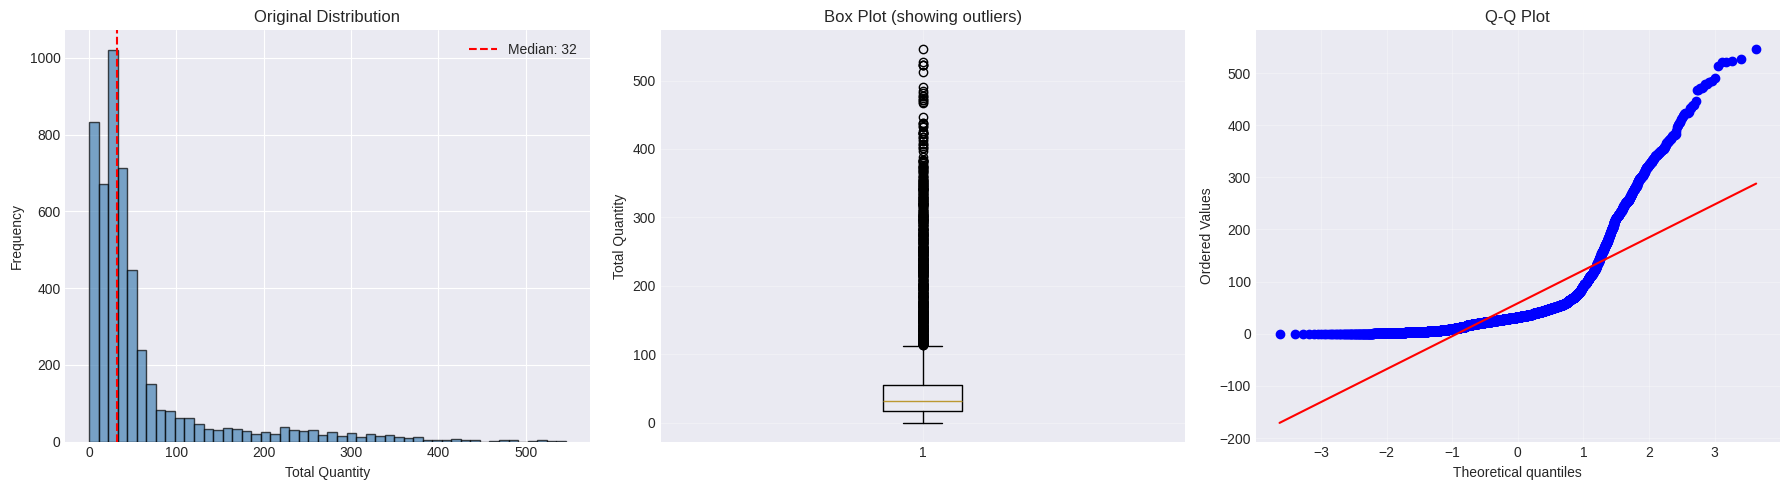


Skewness: 2.70
Kurtosis: 7.71


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df_original['total_quantity'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Total Quantity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution')
axes[0].axvline(df_original['total_quantity'].median(), color='red', linestyle='--', label=f'Median: {df_original["total_quantity"].median():.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df_original['total_quantity'], vert=True)
axes[1].set_ylabel('Total Quantity')
axes[1].set_title('Box Plot (showing outliers)')
axes[1].grid(True, alpha=0.3)

# Q-Q plot
sp_stats.probplot(df_original['total_quantity'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSkewness: {df_original['total_quantity'].skew():.2f}")
print(f"Kurtosis: {df_original['total_quantity'].kurtosis():.2f}")

## 4. Run Cleaning Pipeline



In [14]:
# ── Step 1: Load raw data once ───────────────────────────────────────────────
df_raw = cleaner.load_data()

# ── Step 2: SARIMA branch — cap outliers, then process ───────────────────────
# SARIMA is a linear model sensitive to spikes, so capping is appropriate.
df_sarima = cleaner.handle_outliers(df_raw.copy())
df_sarima = cleaner.handle_incomplete_periods(df_sarima)
df_sarima = cleaner.apply_transformations(df_sarima)

# ── Step 3: XGBoost branch — skip capping, same structural steps ─────────────
# XGBoost is tree-based and cannot extrapolate beyond its training range.
# Training on capped data prevents it from learning high-demand patterns.
df_xgboost = cleaner.handle_incomplete_periods(df_raw.copy())
df_xgboost = cleaner.apply_transformations(df_xgboost)

# ── df_cleaned = SARIMA version (keeps all downstream cells working) 
df_cleaned = df_sarima
validation  = cleaner.validate_data(df_cleaned)
cleaner.save_cleaned_data(df_cleaned)   # saves sales_cleaned.csv as before

print("\n" + "="*60)
print("CLEANING RESULTS")
print("="*60)
print(f"Records before:                  {cleaner.cleaning_stats['initial_records']:,}")
print(f"Records after:                   {cleaner.cleaning_stats['final_records']:,}")
print(f"Outliers capped (SARIMA branch): {cleaner.cleaning_stats.get('outliers_capped', 0):,}")
print(f"XGBoost branch:                  no capping applied (raw values preserved)")
print(f"Quality score:                   {validation['quality_score']:.2f}%")


2026-02-27 23:24:34,664 - INFO - Loading data from database...
2026-02-27 23:24:34,718 - INFO - ✓ Loaded 4,972 records from 2013-12-30 to 2025-12-22
2026-02-27 23:24:34,719 - INFO - 
2026-02-27 23:24:34,719 - INFO - OUTLIER DETECTION AND TREATMENT
2026-02-27 23:24:34,720 - INFO - ============================================================
2026-02-27 23:24:34,720 - INFO - Method: iqr, Action: cap
2026-02-27 23:24:34,724 - INFO - IQR Method: Lower=-39.00, Upper=113.00
2026-02-27 23:24:34,725 - INFO - Found 647 outliers (13.01%)
2026-02-27 23:24:34,726 - INFO - ✓ Capped 647 outlier values
2026-02-27 23:24:34,727 - INFO - 
2026-02-27 23:24:34,728 - INFO - INCOMPLETE PERIOD HANDLING
2026-02-27 23:24:34,728 - INFO - ============================================================
2026-02-27 23:24:34,730 - INFO - Week counts by year:
2026-02-27 23:24:34,731 - INFO -   2014: 52 weeks - ✓ Complete
2026-02-27 23:24:34,731 - INFO -   2015: 53 weeks - ✓ Complete
2026-02-27 23:24:34,732 - INFO -   201


CLEANING RESULTS
Records before:                  4,972
Records after:                   4,972
Outliers capped (SARIMA branch): 647
XGBoost branch:                  no capping applied (raw values preserved)
Quality score:                   100.00%


## 5. Visualize Cleaned Data

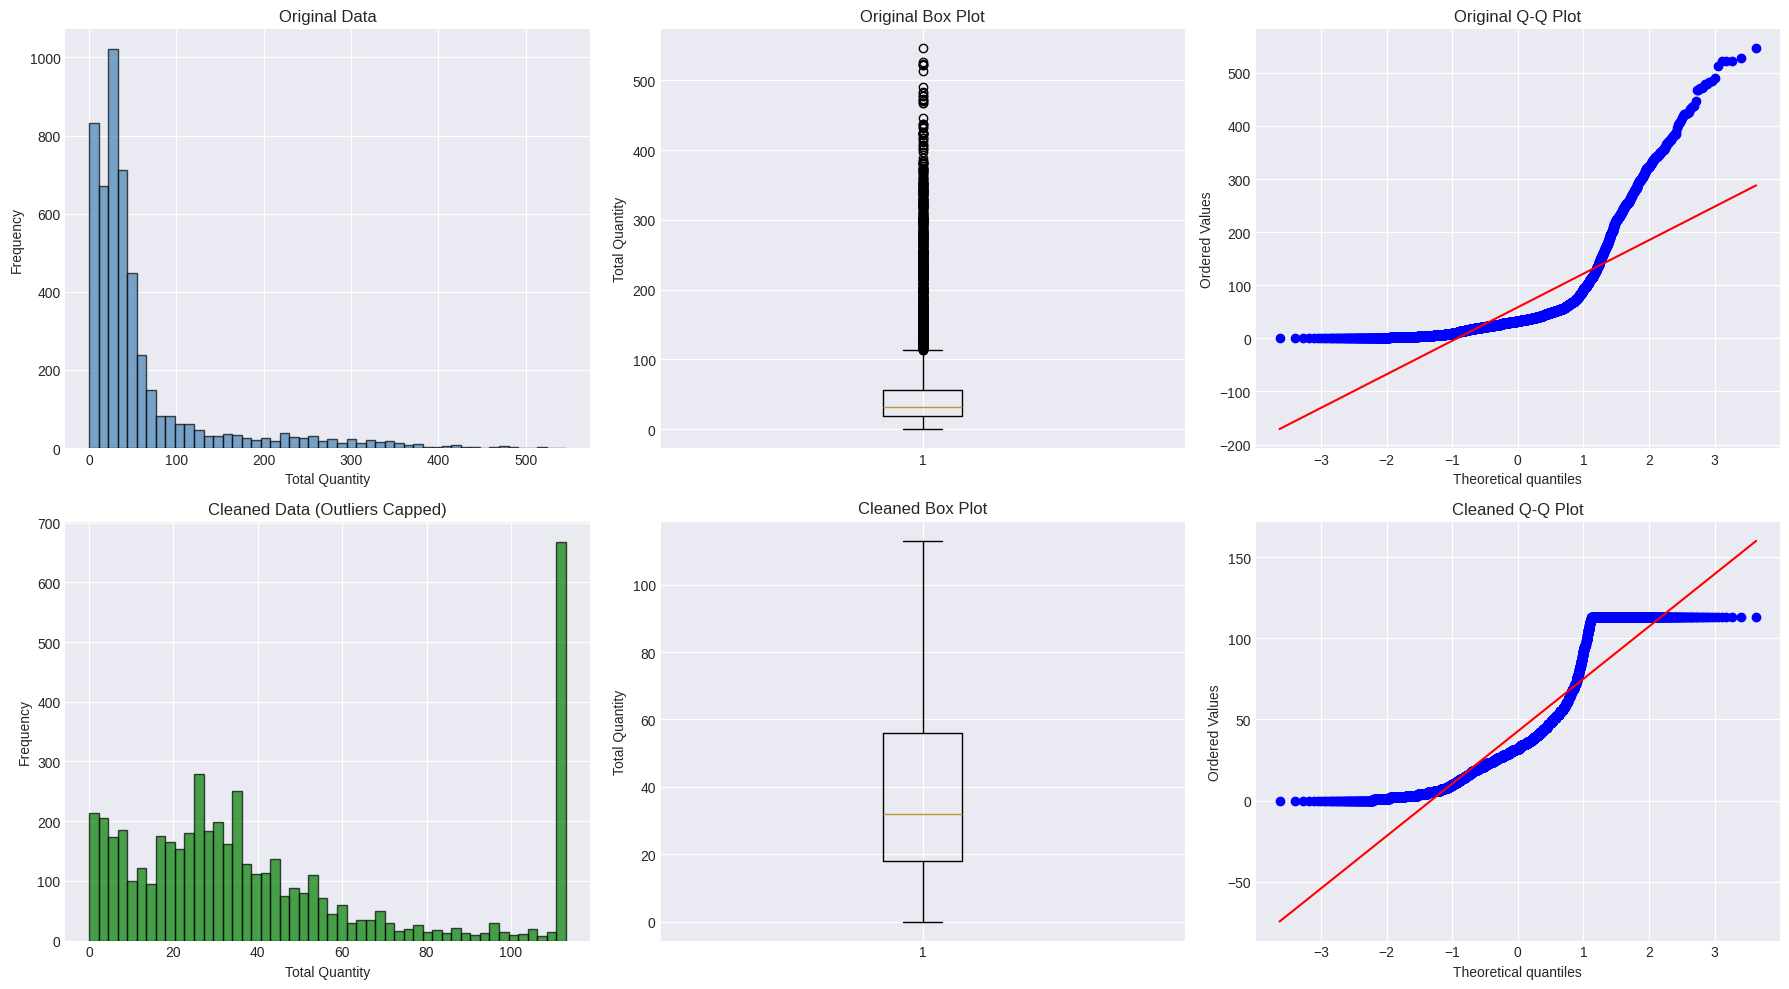


Distribution Comparison:
Metric                      Original         Cleaned          Change
Mean                           58.62           42.78          -15.84
Median                         32.00           32.00           +0.00
Std Dev                        78.75           34.90          -43.85
Skewness                        2.70            0.96           -1.74
Min                             0.00            0.00           +0.00
Max                           546.00          113.00         -433.00


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Original data
axes[0, 0].hist(df_original['total_quantity'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Original Data')
axes[0, 0].set_xlabel('Total Quantity')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].boxplot(df_original['total_quantity'])
axes[0, 1].set_title('Original Box Plot')
axes[0, 1].set_ylabel('Total Quantity')

sp_stats.probplot(df_original['total_quantity'], dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Original Q-Q Plot')

# Cleaned data
axes[1, 0].hist(df_cleaned['total_quantity'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Cleaned Data (Outliers Capped)')
axes[1, 0].set_xlabel('Total Quantity')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].boxplot(df_cleaned['total_quantity'])
axes[1, 1].set_title('Cleaned Box Plot')
axes[1, 1].set_ylabel('Total Quantity')

sp_stats.probplot(df_cleaned['total_quantity'], dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Cleaned Q-Q Plot')

plt.tight_layout()
plt.show()

print("\nDistribution Comparison:")
print(f"{'Metric':<20s} {'Original':>15s} {'Cleaned':>15s} {'Change':>15s}")
print("="*65)

metrics = {
    'Mean': (df_original['total_quantity'].mean(), df_cleaned['total_quantity'].mean()),
    'Median': (df_original['total_quantity'].median(), df_cleaned['total_quantity'].median()),
    'Std Dev': (df_original['total_quantity'].std(), df_cleaned['total_quantity'].std()),
    'Skewness': (df_original['total_quantity'].skew(), df_cleaned['total_quantity'].skew()),
    'Min': (df_original['total_quantity'].min(), df_cleaned['total_quantity'].min()),
    'Max': (df_original['total_quantity'].max(), df_cleaned['total_quantity'].max())
}

for metric, (orig, clean) in metrics.items():
    change = clean - orig
    print(f"{metric:<20s} {orig:>15.2f} {clean:>15.2f} {change:>+15.2f}")

## 6. Compare Log-Transformed Data

In [16]:
if 'total_quantity_log' in df_cleaned.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Original scale
    axes[0].hist(df_cleaned['total_quantity'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].set_title(f'Original Scale (Skewness: {df_cleaned["total_quantity"].skew():.2f})')
    axes[0].set_xlabel('Total Quantity')
    axes[0].set_ylabel('Frequency')
    
    # Log scale
    axes[1].hist(df_cleaned['total_quantity_log'], bins=50, color='green', alpha=0.7, edgecolor='black')
    axes[1].set_title(f'Log-Transformed (Skewness: {df_cleaned["total_quantity_log"].skew():.2f})')
    axes[1].set_xlabel('Log(Total Quantity)')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Log transformation successfully reduced skewness")
    print(f"  Original skewness: {df_cleaned['total_quantity'].skew():.2f}")
    print(f"  Log skewness: {df_cleaned['total_quantity_log'].skew():.2f}")
    print(f"  Improvement: {df_cleaned['total_quantity'].skew() - df_cleaned['total_quantity_log'].skew():.2f}")

## 7. Inspect Incomplete Periods

In [17]:
# Year completeness analysis
year_summary = df_cleaned.groupby('year').agg({
    'week_number': 'nunique',
    'total_quantity': ['sum', 'mean'],
    'is_complete_year': 'first'
}).round(2)

year_summary.columns = ['Weeks', 'Total_Sales', 'Avg_Weekly_Sales', 'Complete']
print("\nYear Completeness Summary:")
print(year_summary)

# Incomplete year records
incomplete_records = df_cleaned[~df_cleaned['is_complete_year']]
print(f"\n⚠ Records in incomplete years: {len(incomplete_records):,} ({len(incomplete_records)/len(df_cleaned)*100:.1f}%)")
print(f"Incomplete years: {cleaner.cleaning_stats['incomplete_years']}")

# Recommendation
print("\n💡 Recommendation:")
print("   For time series modeling, consider:")
print("   - Using only complete years for training")
print("   - Or apply seasonal adjustment for incomplete periods")
print("   - Flag 'is_complete_year' can be used for filtering")


Year Completeness Summary:
      Weeks  Total_Sales  Avg_Weekly_Sales  Complete
year                                                
2014     52        16509             39.88      True
2015     53        16852             40.41      True
2016     52        17651             43.16      True
2017     52        15788             38.89      True
2018     52        17385             42.71      True
2019     52        17263             41.60      True
2020     53        19386             45.72      True
2021     52        19134             46.00      True
2022     52        18728             45.02      True
2023     52        18085             43.47      True
2024     52        17813             42.82      True
2025     52        18095             43.50      True

⚠ Records in incomplete years: 0 (0.0%)
Incomplete years: []

💡 Recommendation:
   For time series modeling, consider:
   - Using only complete years for training
   - Or apply seasonal adjustment for incomplete periods
   - Flag

## 8. Review Cleaned Data

In [18]:
print("="*60)
print("CLEANED DATA SUMMARY")
print("="*60)
print(f"\nShape: {df_cleaned.shape}")
print(f"\nColumns: {list(df_cleaned.columns)}")
print(f"\nDate range: {df_cleaned['week_start_date'].min().date()} to {df_cleaned['week_start_date'].max().date()}")
print(f"\nData Quality Score: {validation['quality_score']:.2f}%")

print("\nNew columns added:")
print("  • total_quantity_log: Log-transformed values (for modeling)")
print("  • total_quantity_scaled: Standardized values (mean=0, std=1)")
print("  • is_complete_year: Flag for complete/incomplete years")

df_cleaned.head(10)

CLEANED DATA SUMMARY

Shape: (4972, 11)

Columns: ['year', 'week_number', 'week_start_date', 'week_end_date', 'total_quantity', 'avg_daily_quantity', 'drug_name', 'atc_code', 'drug_id', 'is_complete_year', 'total_quantity_scaled']

Date range: 2013-12-30 to 2025-12-22

Data Quality Score: 100.00%

New columns added:
  • total_quantity_log: Log-transformed values (for modeling)
  • total_quantity_scaled: Standardized values (mean=0, std=1)
  • is_complete_year: Flag for complete/incomplete years


,year,week_number,week_start_date,week_end_date,total_quantity,avg_daily_quantity,drug_name,atc_code,drug_id,is_complete_year,total_quantity_scaled
0,2014,1,2013-12-30,2014-01-05,14,2.00,M01AB,M01AB,1,True,-0.824734
1,2014,1,2013-12-30,2014-01-05,11,1.67,M01AE,M01AE,2,True,-0.910712
2,2014,1,2013-12-30,2014-01-05,21,3.04,N02BA,N02BA,3,True,-0.624120
3,2014,1,2013-12-30,2014-01-05,113,26.56,N02BE,N02BE,4,True,2.012521
4,2014,1,2013-12-30,2014-01-05,41,5.86,N05B,N05B,5,True,-0.050937
5,2014,1,2013-12-30,2014-01-05,32,4.57,R03,R03,7,True,-0.308870
6,2014,1,2013-12-30,2014-01-05,7,1.00,R06,R06,8,True,-1.025348
7,2014,2,2014-01-06,2014-01-12,29,4.19,M01AB,M01AB,1,True,-0.394847
8,2014,2,2014-01-06,2014-01-12,12,1.81,M01AE,M01AE,2,True,-0.882053
9,2014,2,2014-01-06,2014-01-12,37,5.41,N02BA,N02BA,3,True,-0.165574


## 9. Save and Export

In [19]:
output_path = Path(project_root) / 'data' / 'processed' / 'sales_cleaned.csv'
print(f"✓ Cleaned data saved to: {output_path}")
print(f"✓ File size: {output_path.stat().st_size / 1024:.2f} KB")

# ── SARIMA modeling file (outliers capped, complete years only) ───────────────
df_modeling_sarima = df_cleaned[df_cleaned['is_complete_year']].copy()
sarima_path = Path(project_root) / 'data' / 'processed' / 'sales_modeling_sarima.csv'
df_modeling_sarima.to_csv(sarima_path, index=False)
print(f"\n✓ SARIMA modeling dataset  → {sarima_path}")
print(f"  Records : {len(df_modeling_sarima):,} (complete years, outliers capped at IQR bounds)")
print(f"  File size: {sarima_path.stat().st_size / 1024:.2f} KB")

# ── XGBoost modeling file (raw uncapped values, complete years only) ──────────
df_modeling_xgboost = df_xgboost[df_xgboost['is_complete_year']].copy()
xgboost_path = Path(project_root) / 'data' / 'processed' / 'sales_modeling_xgboost.csv'
df_modeling_xgboost.to_csv(xgboost_path, index=False)
print(f"\n✓ XGBoost modeling dataset → {xgboost_path}")
print(f"  Records : {len(df_modeling_xgboost):,} (complete years, full raw demand range)")
print(f"  File size: {xgboost_path.stat().st_size / 1024:.2f} KB")

# ── Verify the difference in N02BE range between the two files ────────────────
n02be_sarima  = df_modeling_sarima[df_modeling_sarima['drug_name'].str.contains('N02BE', na=False)]['total_quantity']
n02be_xgboost = df_modeling_xgboost[df_modeling_xgboost['drug_name'].str.contains('N02BE', na=False)]['total_quantity']
print(f"\nN02BE total_quantity range check:")
print(f"  SARIMA  file: {n02be_sarima.min():.2f} – {n02be_sarima.max():.2f}  (capped)")
print(f"  XGBoost file: {n02be_xgboost.min():.2f} – {n02be_xgboost.max():.2f}  (raw)")

# ── Legacy alias: keep sales_modeling.csv pointing at SARIMA version ──────────
modeling_path = Path(project_root) / 'data' / 'processed' / 'sales_modeling.csv'
df_modeling_sarima.to_csv(modeling_path, index=False)
print(f"\n✓ Legacy sales_modeling.csv updated (mirrors SARIMA version for backward compatibility)")


✓ Cleaned data saved to: /home/brenda/final year project/PharmacyForecastingSystem/data/processed/sales_cleaned.csv
✓ File size: 365.44 KB

✓ SARIMA modeling dataset  → /home/brenda/final year project/PharmacyForecastingSystem/data/processed/sales_modeling_sarima.csv
  Records : 4,972 (complete years, outliers capped at IQR bounds)
  File size: 365.44 KB

✓ XGBoost modeling dataset → /home/brenda/final year project/PharmacyForecastingSystem/data/processed/sales_modeling_xgboost.csv
  Records : 4,972 (complete years, full raw demand range)
  File size: 454.71 KB

N02BE total_quantity range check:
  SARIMA  file: 0.00 – 113.00  (capped)
  XGBoost file: 0.00 – 546.00  (raw)

✓ Legacy sales_modeling.csv updated (mirrors SARIMA version for backward compatibility)
